# Supplementary data analyses: normalization, spectrum, and convergence

Follow-ups to the data-driven ring attractor built from the Peyrache mouse HD recordings. Produces Supplementary Figs. S7 (`double_normalization.pdf`), S8 (`pca_convergence.png`), S14 (`data_and_subsample_spectra.png`), and S9 (`error_vs_regularization.pdf`).

In [ ]:
# Regeneration switches (default off so a normal run cannot overwrite committed figures/caches):
SAVE_FIGURES = False
REGENERATE_CACHES = False


import numpy as np
import matplotlib.pyplot as plt
import scipy.io as sio
from scipy.interpolate import interp1d

from ring import data_driven, style
from importlib import reload
reload(data_driven)

import numpy as np
from scipy.ndimage import gaussian_filter1d
import matplotlib.pyplot as plt
import numpy as np
import scipy


## Load tuning curves and fit the weight matrix

`load_data_Phi` returns the cross-validated, smoothed, per-neuron-normalized tuning curves. `prepare_smoothed_normalized_resampled_tuning_curves_OLD` then applies the legacy Gaussian-smoothing + Sinkhorn normalization used for the attractor construction; `compute_weights` solves the ridge regression `X ≈ Φ Jᵀ`. The `_OLD` variant is called deliberately — it is what produced the published figures.

In [20]:
reload(data_driven)

# Load data
Phi_raw = data_driven.load_data_Phi()

# Compute weights

# Compute 'old' weights
X, Phi = data_driven.prepare_smoothed_normalized_resampled_tuning_curves_OLD(Phi_raw, N_theta=10000)
J, J_prime = data_driven.compute_weights(X, Phi, lamda=1e-8)


print("err =", np.mean((X - Phi @ J.T)**2))


err = 8.538735834894397e-10


In [77]:
Phi.mean(1)

array([1.00000007, 1.00000007, 1.00000007, ..., 1.00000008, 1.00000008,
       1.00000008])

## Supplementary Figure S14 (left) — eigenvalues and singular vectors of the data-fit `J`

Spectrum of the fitted weight matrix and the leading left singular vectors of `Φ`. The near-degenerate cluster of real eigenvalues just above 1 (boxed in the complex-plane panel) is the signature of the continuous attractor. The compose cell below re-renders this content as the left half of Supplementary Fig. S14.

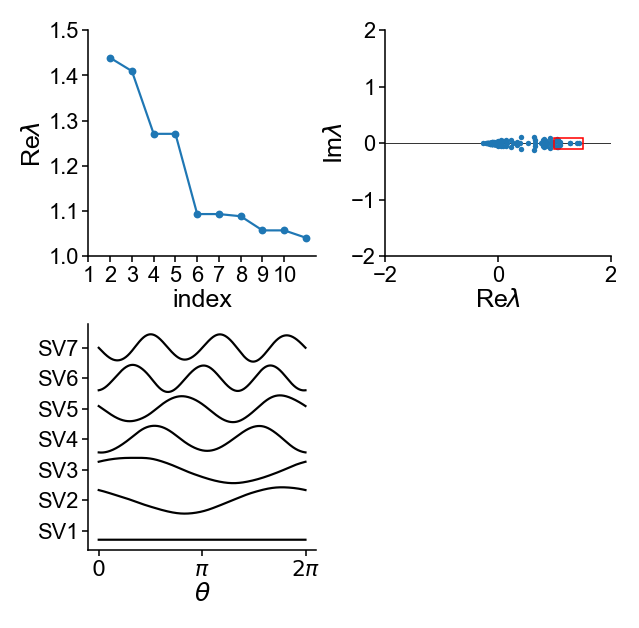

In [72]:
w = np.linalg.eigvals(J)
U, s, Vt = np.linalg.svd(Phi)
V = Vt.T

fig = plt.figure(figsize=(3, 3))
gs = fig.add_gridspec(2, 2, height_ratios=[1, 1], width_ratios=[1, 1], hspace=0.3, wspace=0.3)

# Top left: Real eigenvalues
ax_eig = fig.add_subplot(gs[0, 0])
ax_eig.plot(np.arange(10)+1, np.sort(w.real)[::-1][:10], marker='.', mew=0, ms=5, clip_on=False)
ax_eig.set_xlabel("index")
ax_eig.set_ylabel("Re$\\lambda$")
ax_eig.set_xticks(np.arange(10) + 1)
ax_eig.set_xticklabels(np.arange(10)+1)
ax_eig.set_ylim(1, 1.5)

# Top right: Complex plane
ax_complex = fig.add_subplot(gs[0, 1])
ax_complex.scatter(w.real, w.imag, lw=0, s=3)
ax_complex.axhline(0, c='black', zorder=0, lw=0.25)
x1, x2 = 1., 1.5
y1, y2 = -0.1, 0.1
ax_complex.add_patch(plt.Rectangle((x1, y1), x2-x1, y2-y1, fill=False, edgecolor='red', linewidth=0.5))
ax_complex.set_aspect(1.)
ax_complex.set_xlim(-2, 2)
ax_complex.set_ylim(-2, 2)
ax_complex.set_xlabel("Re$\\lambda$")
ax_complex.set_ylabel("Im$\\lambda$")

# Bottom left: SVs (same width as top left)
ax_sv = fig.add_subplot(gs[1, 0])
for i in range(7):
    ax_sv.plot(np.arange(len(U))*2*np.pi/len(U), U[:, i]*30 + i, color='black')
ax_sv.set_yticks(np.arange(7))
ax_sv.set_yticklabels(['SV'+str(i+1) for i in range(7)])
ax_sv.set_xticks([0, np.pi, 2*np.pi])
ax_sv.set_xticklabels(["$0$", "$\\pi$", "$2\\pi$"])
ax_sv.set_xlabel("$\\theta$")

plt.show()

In [ ]:
"""
Compose Supplementary Fig. S14 in full: data-fit spectrum (a) + subsample convergence (b).

Draws both panels in one cell, into one code-composed figure,
analogous to the main-text compose cells. Both panels are re-rendered
into a single master gridspec; only the arrangement changes.
  A  eigenvalues + leading singular vectors of the mouse-data-fit `J`
     (reuses `J`, `Phi` computed above; deterministic, pixel-exact)
  B  Re-lambda decay + singular vectors across population size N = 100/500/1000/1533,
     built here from idealized tuning curves via `gen_tuning_curves_idealized`
     (the same computation as weight_matrix_analyses.ipynb).

Panel A carries no RNG and is bit-for-bit the same as the old `data_spectrum.pdf`.
Panel B draws idealized populations from the global numpy RNG, so
`np.random.seed(42)` is set immediately before its loop to make the realization
deterministic. Because this seeded draw has a different RNG history than the old
standalone `subsample_spectrum.pdf`, panel B is a fresh TIER-3-STATISTICAL
realization: it matches the committed figure in decay shape and singular-vector
structure, not pixel-for-pixel.
"""
from matplotlib.gridspec import GridSpecFromSubplotSpec
from ring.tc import gen_tuning_curves_idealized

# --- Panel A quantities (mouse-data fit; identical to the data_spectrum cell) ---
w = np.linalg.eigvals(J)
U, s, Vt = np.linalg.svd(Phi)

# --- Panel B parameters (idealized tuning curves) ---
beta, scale, lamda_sub, N_theta_sub = 2.7659, 1.4211, 1e-8, 500
N_values = [100, 500, 1000, 1533]

fig = plt.figure(figsize=(style.FULL_W, 3.2), dpi=100)
outer = fig.add_gridspec(1, 2, width_ratios=[2, 5], wspace=0.12,
                         left=0.05, right=0.985, top=0.90, bottom=0.14)

# ============ Panel A: 2x2, using [0,0], [0,1], [1,0] (bottom-right blank) ============
gsA = GridSpecFromSubplotSpec(2, 2, subplot_spec=outer[0],
                              height_ratios=[1, 1], hspace=0.45, wspace=0.55)

ax_eig = fig.add_subplot(gsA[0, 0])
ax_eig.plot(np.arange(10)+1, np.sort(w.real)[::-1][:10], marker='.', mew=0, ms=5, clip_on=False)
ax_eig.set_xlabel("index")
ax_eig.set_ylabel("Re$\\lambda$")
ax_eig.set_xticks(np.arange(10) + 1)
ax_eig.set_xticklabels(np.arange(10)+1)
ax_eig.set_ylim(1, 1.5)

ax_complex = fig.add_subplot(gsA[0, 1])
ax_complex.scatter(w.real, w.imag, lw=0, s=3)
ax_complex.axhline(0, c='black', zorder=0, lw=0.25)
x1, x2 = 1., 1.5
y1, y2 = -0.1, 0.1
ax_complex.add_patch(plt.Rectangle((x1, y1), x2-x1, y2-y1, fill=False, edgecolor=style.CRIMSON, linewidth=0.5))
ax_complex.set_aspect(1.)
ax_complex.set_xlim(-2, 2)
ax_complex.set_ylim(-2, 2)
ax_complex.set_xlabel("Re$\\lambda$")
ax_complex.set_ylabel("Im$\\lambda$")

ax_sv = fig.add_subplot(gsA[1, 0])
for i in range(7):
    ax_sv.plot(np.arange(len(U))*2*np.pi/len(U), U[:, i]*30 + i, color='black')
ax_sv.set_yticks(np.arange(7))
ax_sv.set_yticklabels(['SV'+str(i+1) for i in range(7)])
ax_sv.set_xticks([0, np.pi, 2*np.pi])
ax_sv.set_xticklabels(["$0$", "$\\pi$", "$2\\pi$"])
ax_sv.set_xlabel("$\\theta$")

# ============ Panel B: 2x4 (top = Re-lambda decay, bottom = SV stacks) ============
gsB = GridSpecFromSubplotSpec(2, 4, subplot_spec=outer[1],
                              height_ratios=[1, 1], hspace=0.45, wspace=0.4)
np.random.seed(42)  # deterministic subsample realization (TIER-3; see docstring)
ax_eig_B0 = None
for col, N_data in enumerate(N_values):
    Xb, Phib = gen_tuning_curves_idealized(N_samples=N_data, N_theta=N_theta_sub,
                                           scale=scale, beta=beta)
    Jb, Jb_uc = data_driven.compute_weights(X=Xb, Phi=Phib, lamda=lamda_sub)
    wb = np.linalg.eigvals(Jb)
    Ub, sb, Vtb = np.linalg.svd(Phib)

    axe = fig.add_subplot(gsB[0, col])
    axe.plot(np.arange(10)+1, wb.real[np.argsort(wb.real)[::-1]][:10], marker='.', clip_on=False)
    axe.set_title(f'N={N_data}')
    if col == 0:
        axe.set_ylabel('Re$\\lambda$')
        ax_eig_B0 = axe
    axe.set_ylim(0, 1.5)
    axe.set_xlabel("index")

    axsv = fig.add_subplot(gsB[1, col])
    for i in range(7):
        mode = Ub[:, i]
        normalized_mode = 6 * mode / np.sqrt((mode**2).sum())
        axsv.plot(np.arange(len(Ub))*2*np.pi/len(Ub), normalized_mode + i, color='black')
    axsv.set_yticks(np.arange(7))
    axsv.set_yticklabels(['SV'+str(i+1) for i in range(7)])
    axsv.set_xticks([0, np.pi, 2*np.pi])
    axsv.set_xticklabels(["$0$", "$\\pi$", "$2\\pi$"])
    axsv.set_xlabel("$\\theta$")

# --- panel letters ---
LETTER_KW = dict(fontsize=8, fontweight='bold', va='bottom', ha='right')
ax_eig.text(-0.45, 1.08, 'a', transform=ax_eig.transAxes, **LETTER_KW)
ax_eig_B0.text(-0.42, 1.20, 'b', transform=ax_eig_B0.transAxes, **LETTER_KW)

if SAVE_FIGURES:
    plt.savefig("../figures/data_and_subsample_spectra.png", bbox_inches="tight", dpi=400)
plt.show()

In [34]:
Phi_downsampled = Phi[::100] #since preprocessing of Phi upsampels by a factor of 100 compared to 100 bins

Phi_raw.shape, Phi_downsampled.shape

((100, 1533), (100, 1533))

## Supplementary Figure S7 — effect of the extra cross-neuron normalization

Compares the tuning curves used throughout the paper (cross-validated smoothing, per-neuron normalized; teal) against the curves used only for the network construction, which carry two further steps, a 2-bin Gaussian smoothing of the input currents and the Sinkhorn cross-neuron normalization (orange), for 25 randomly chosen units plus the population mean. The point is that the second normalization flattens `N⁻¹ Σᵢ φᵢ(θ)` without materially distorting single-unit tuning. `np.random.seed(42)` fixes which 25 units are shown.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(style.FULL_W, 6.5))  # FULL_W-wide supplement canvas
gs = gridspec.GridSpec(
    7, 5, figure=fig, hspace=1,
    height_ratios=[0.2, 1, 1, 1, 1, 1, 1.5]  # row 0 for legend, 1–5 for grid, 6 for summary
)

theta = np.arange(Phi_raw.shape[0]) * 2*np.pi / Phi_raw.shape[0]
np.random.seed(42)
neuron_indices = np.sort(np.random.choice(np.arange(Phi_raw.shape[1]), size=25, replace=False))

# --- 5x5 grid ---
axes = []
for i, neuron_idx in enumerate(neuron_indices):
    r, c = divmod(i, 5)
    ax = fig.add_subplot(gs[r+1, c])  # rows 1–5
    line1, = ax.plot(theta, Phi_raw[:, neuron_idx], c=style.LINE_A, lw=0.5,
                     label="cross-validated, smoothed, single-neuron normalized (used throughout paper)")
    line2, = ax.plot(theta, Phi_downsampled[:, neuron_idx], c=style.LINE_B, lw=0.5,
                     label="plus input-current smoothing and cross-neuron normalization (for network construction)")
    ax.set_xticks([0, np.pi, 2*np.pi])
    ax.set_xticklabels(["$0$", "$\\pi$", "$2\\pi$"])
    ax.set_ylim(-0.1, 10)
    axes.append(ax)

# --- Summary panel (row 6, spanning all 5 columns) ---
ax_summary = fig.add_subplot(gs[6, :])
ax_summary.plot(theta, Phi_raw.mean(1), c=style.LINE_A)
ax_summary.plot(theta, Phi_downsampled.mean(1), c=style.LINE_B)
ax_summary.set_xticks([0, np.pi, 2*np.pi])
ax_summary.set_xticklabels(["$0$", "$\\pi$", "$2\\pi$"])
ax_summary.set_ylim(0, 1.1)
ax_summary.set_xlabel("$\\theta$")
ax_summary.set_ylabel("$N^{-1} \\sum_{i=1}^N \\phi^{\\star}_i(\\theta)$",
                     rotation=0, va='center', ha='right', labelpad=10)

# --- Panel letters: a labels the 5x5 grid, b the summary panel ---
# x = -0.15 clears the y tick labels of the first grid panel, which the default
# -0.02 runs into. Both blocks start at the same left edge, but panel_letter's
# offset is in axes fractions, so the wide summary axes needs it rescaled by the
# width ratio to put b at the same figure x as a.
LETTER_X = -0.15
style.panel_letter(axes[0], 'a', x=LETTER_X)
style.panel_letter(
    ax_summary, 'b',
    x=LETTER_X * axes[0].get_position().width / ax_summary.get_position().width,
)

# --- Legend (row 0, above everything) ---
fig.legend(
    [line1, line2],
    [line1.get_label(), line2.get_label()],
    loc="upper center",
    bbox_to_anchor=(0.5, 0.89),
    ncol=1,
)

if SAVE_FIGURES:
    plt.savefig("../figures/double_normalization.pdf", bbox_inches='tight')


## Convergence onto the attractor from noisy initial conditions

Single-`λ` warm-up for the grid below: integrate from 100 perturbed initial conditions and project onto the tuning-curve PCs. The next two cells are quick shape/plot checks. Requires a GPU (`data_driven.run_simulation` uses `device=0`). The `run_convergence_analysis` defined in this cell is a distinct function from the same-named one defined further down — see the note there.

err = 8.538735834894397e-10
(1533, 100)


100%|█████████████████████████████████████| 5999/5999 [00:03<00:00, 1881.06it/s]


(-50.0, 50.0)

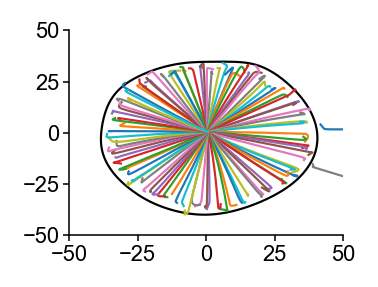

In [6]:
reload(data_driven)
import torch

# Define T and tau
T, tau = 30, 0.05
T_eval = tau #/ 5.
dt = tau / 10.

# Fit weights
lamda = 1e-8
J, J_prime = data_driven.compute_weights(X, Phi, lamda=lamda)

# This error IS saved, by the convergence-grid cell below, which recomputes it for
# every lamda in lamda_vals and writes it to pc_convergence_grid.npz as err_grid.
# lamda_vals contains this cell's lamda, so err_grid[2, 0] is exactly this number.
print("err =", np.mean((X - Phi @ J.T)**2))

def run_convergence_analysis(N_ics=100):
    # Run simulation for multiple initial conditions
    noise_std = 3.
    x_init_noiseless = X[::int(X.shape[0] / N_ics)].copy().T
    x_init = x_init_noiseless + np.random.randn(*x_init_noiseless.shape) * noise_std
    print(x_init.shape)
    x_save = data_driven.run_simulation(J, x_init, T=T, tau=tau, dt=dt, T_eval=T_eval, c_const=0.)
    # Compute PCA
    pcs, pcs_traj = data_driven.do_pca_on_tcs_and_trajectories(Phi, data_driven.nonlin(torch.Tensor(x_save).to('cuda' if torch.cuda.is_available() else 'cpu')).cpu().numpy())
    return pcs, pcs_traj

pcs, pcs_traj = run_convergence_analysis()

for ic_idx in range(100):
    plt.plot(pcs_traj[:, 0, ic_idx], pcs_traj[:, 1, ic_idx])
plt.plot(pcs[:, 0], pcs[:, 1], c='black', zorder=0)
plt.xlim(-50, 50)
plt.ylim(-50, 50)

In [26]:
pcs_traj.shape

(3000, 3, 100)

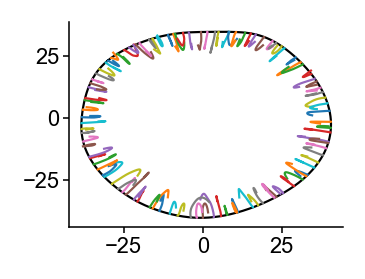

In [17]:
for ic_idx in range(100):
    plt.plot(pcs_traj[:, 0, ic_idx], pcs_traj[:, 1, ic_idx])
plt.plot(pcs[:, 0], pcs[:, 1], c='black', zorder=0)

## Convergence grid over `λ` and `c` (cache producer)

Sweeps 6 ridge values × 7 constant-input scales, saving the PC trajectories and reconstruction error to `../data/pc_convergence_grid.npz` (67 MB). The driving call `compute_and_save_grid()` at the bottom is **guarded by `REGENERATE_CACHES`** (default `False`): the cached grid is the verified baseline consumed by the next two figures, and re-running would overwrite it. The `np.random.seed(42)` inside `run_convergence_analysis` pins its initial-condition noise.

**Note on the two `run_convergence_analysis` functions:** this cell redefines a function of the same name as the one in the warm-up cell above. They are intentionally distinct — this version takes `J`/`c_const` and seeds its noise, the earlier one does not — and each is called only within its own cell. The redefinition is deliberate, not an accident; a top-to-bottom run uses this version for the grid.

In [ ]:
# ================================
# Convergence grid: run + save + plot
# ================================

import torch
reload(data_driven)

# --- Grid
c_vals = [0, 0.25, 0.5, 0.75, 1.0, 1.25, 1.5]
# Ten decades of ridge, centred on the operating value lamda = 1e-8 at index 2, which
# is where the old sweep put the old operating value 1e-6. Shifted down two decades
# with the change to the N-normalized convention (see regression.compute_J).
lamda_vals = [1e-12, 1e-10, 1e-8, 1e-6, 1e-4, 1e-2]

# --- Global sim params
T, tau = 30, 0.05
T_eval = tau # tau / 5.
dt = tau / 10. # tau / 50.
N_ics = 100
noise_std = 3.0

# --- Utility: run convergence analysis for given J and c_const
def run_convergence_analysis(J, c_const, N_ics=100):
    np.random.seed(42)
    x_init_noiseless = X[::int(X.shape[0] / N_ics)].copy().T
    x_init = x_init_noiseless + np.random.randn(*x_init_noiseless.shape) * noise_std
    x_save = data_driven.run_simulation(
        J, x_init, T=T, tau=tau, dt=dt, T_eval=T_eval, c_const=c_const
    )
    # Compute PCA on (Phi) + simulated trajectories pushed through nonlin
    pcs, pcs_traj = data_driven.do_pca_on_tcs_and_trajectories(
        Phi,
        data_driven.nonlin(torch.Tensor(x_save).to('cuda' if torch.cuda.is_available() else 'cpu')).cpu().numpy()
    )
    return pcs, pcs_traj

# --- Run the full grid and save
def compute_and_save_grid(filename="../data/pc_convergence_grid.npz"):
    # Pre-allocate lists (we'll stack at the end for safety)
    pcs_list = []
    pcs_traj3_list = []
    err_list = []
    shape_check = {"pcs": None, "pcs_traj3": None}

    for lam_idx, lamda in enumerate(lamda_vals):
        # Fit weights for this lambda
        J, J_prime = data_driven.compute_weights(X, Phi, lamda=lamda)

        # Reconstruction error (as requested to save)
        err = float(np.mean((X - Phi @ J.T) ** 2))
        err_list.append([err for _ in c_vals])  # same err replicated across c row

        row_pcs = []
        row_pcs_traj3 = []

        for c in c_vals:
            pcs, pcs_traj = run_convergence_analysis(J, c_const=c, N_ics=N_ics)

            # Keep only pcs[:, :3] and pcs_traj[:, :3, :]
            pcs3 = pcs[:, :3]
            pcs_traj3 = pcs_traj[:, :3, :]

            # Shape sanity
            if shape_check["pcs"] is None:
                shape_check["pcs"] = pcs3.shape  # (N_theta, 3)
            if shape_check["pcs_traj3"] is None:
                shape_check["pcs_traj3"] = pcs_traj3.shape  # (Tsteps, 3, N_ics)

            row_pcs.append(pcs3)
            row_pcs_traj3.append(pcs_traj3)

        pcs_list.append(row_pcs)
        pcs_traj3_list.append(row_pcs_traj3)

    # Convert to arrays with explicit dtype=object to handle any accidental variation
    pcs_grid = np.empty((len(lamda_vals), len(c_vals)), dtype=object)
    pcs_traj3_grid = np.empty((len(lamda_vals), len(c_vals)), dtype=object)
    for i in range(len(lamda_vals)):
        for j in range(len(c_vals)):
            pcs_grid[i, j] = pcs_list[i][j]
            pcs_traj3_grid[i, j] = pcs_traj3_list[i][j]

    err_grid = np.array(err_list)  # shape: (len(lamda_vals), len(c_vals))

    # Save everything (only pcs and first 3 of pcs_traj are required; include err & params for convenience)
    np.savez(
        filename,
        pcs_grid=pcs_grid,                # object array, each item shape (N_theta, 3)
        pcs_traj3_grid=pcs_traj3_grid,    # object array, each item shape (Tsteps, 3, N_ics)
        err_grid=err_grid,                # float array [lamda_idx, c_idx]
        c_vals=np.array(c_vals),
        lamda_vals=np.array(lamda_vals),
        T=T, tau=tau, dt=dt, T_eval=T_eval, N_ics=N_ics, noise_std=noise_std
    )
    print(f"Saved grid to {filename}")
    return filename

if REGENERATE_CACHES:
    compute_and_save_grid()

## Supplementary Figure S8 — convergence across the (`λ`, `c`) grid

Plots the cached grid: each panel shows 100 trajectories in the PC1–PC2 plane against the black tuning-curve manifold. The `plt.savefig("pca_convergence.png", ...)` is **guarded by `SAVE_FIGURES`** (default `False`) — this cell's output is the locked, byte-exact Fig. S8 baseline, so the save stays off to keep a re-run from clobbering it.

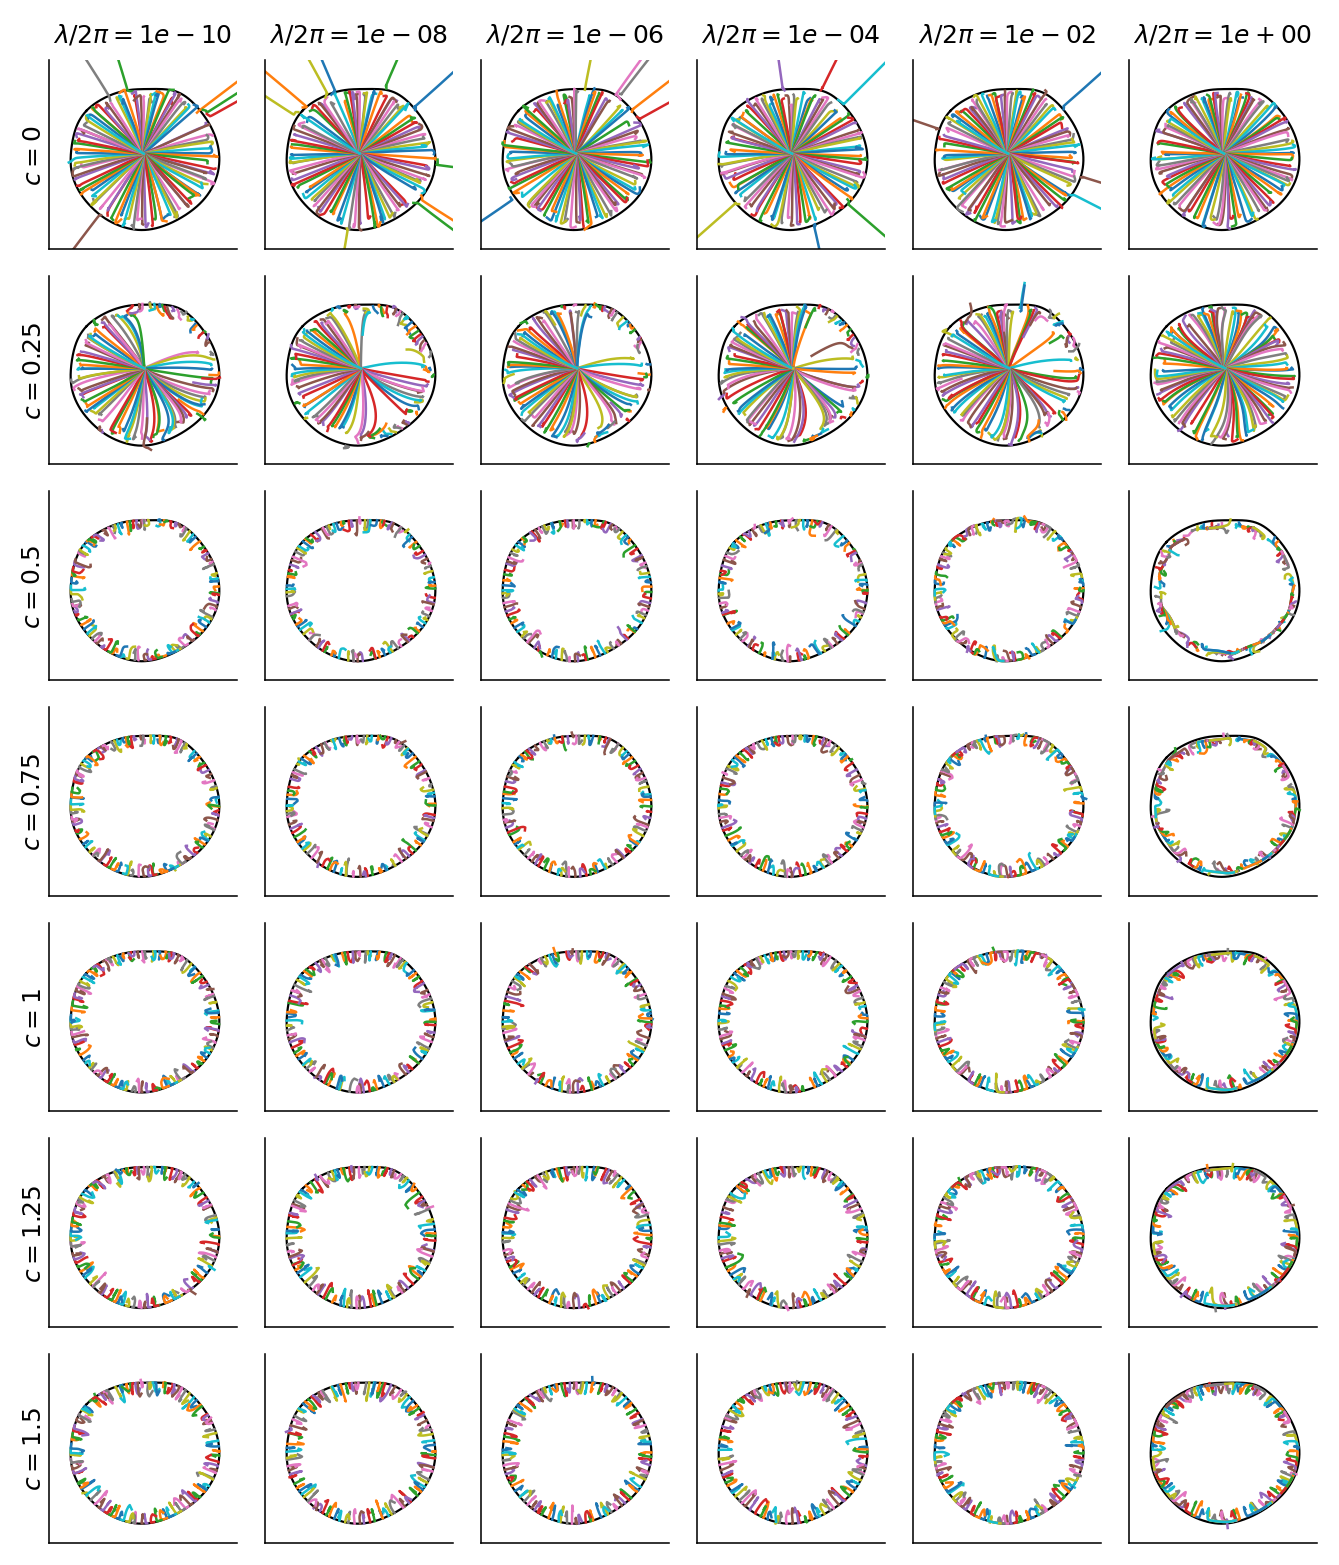

In [5]:
# --- Plotting from saved .npz
def plot_pc_convergence_grid(filename="../data/pc_convergence_grid.npz",
                             xlim=(-50, 50), ylim=(-50, 50),
                             max_traj_per_panel=100):
    data = np.load(filename, allow_pickle=True)
    pcs_grid = data["pcs_grid"]
    pcs_traj3_grid = data["pcs_traj3_grid"]
    c_vals_loaded = data["c_vals"]
    lamda_vals_loaded = data["lamda_vals"]

    n_rows = len(c_vals_loaded)       # rows = c
    n_cols = len(lamda_vals_loaded)   # cols = lambda

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(style.FULL_W, 6.5), squeeze=False)

    for j, lamda in enumerate(lamda_vals_loaded):
        for i, c in enumerate(c_vals_loaded):
            ax = axes[i, j]
            pcs = pcs_grid[j, i]            # (N_theta, 3)
            traj = pcs_traj3_grid[j, i]     # (Tsteps, 3, N_ics)
            # Plot each IC trajectory in PC1-PC2 plane
            n_ics = traj.shape[2]
            n_plot = min(n_ics, max_traj_per_panel)
            ax.set_prop_cycle(color=style.CATEGORICAL)
            for ic_idx in range(n_plot):
                ax.plot(traj[:, 0, ic_idx], traj[:, 1, ic_idx], linewidth=0.8)
            # Plot the principal curve (pc1 vs pc2) in black on top
            ax.plot(pcs[:, 0], pcs[:, 1], c="black", zorder=0)
            ax.set_xlim(*xlim)
            ax.set_ylim(*ylim)
            if i == 0:
                ax.set_title(f"$\\lambda={lamda:.0e}$")
            if j == 0:
                ax.set_ylabel(f"$c={c:g}$")
            ax.set_xticks([])
            ax.set_yticks([])
            ax.set_aspect(1.)

    plt.tight_layout()


plot_pc_convergence_grid("../data/pc_convergence_grid.npz",
                         xlim=(-50, 50), ylim=(-50, 50))
if SAVE_FIGURES:
    plt.savefig("../figures/pca_convergence.png", bbox_inches='tight', dpi=400)



## Supplementary Figure S9 — reconstruction error vs. `λ`

Reads `err_grid[:, 0]` from the same cache (the error is independent of `c`) and plots it against `λ` on log-log, motivating the `λ = 1e-6` used elsewhere. Deterministic — no RNG in this cell.

Text(0, 0.5, 'MSE reconstruction error')

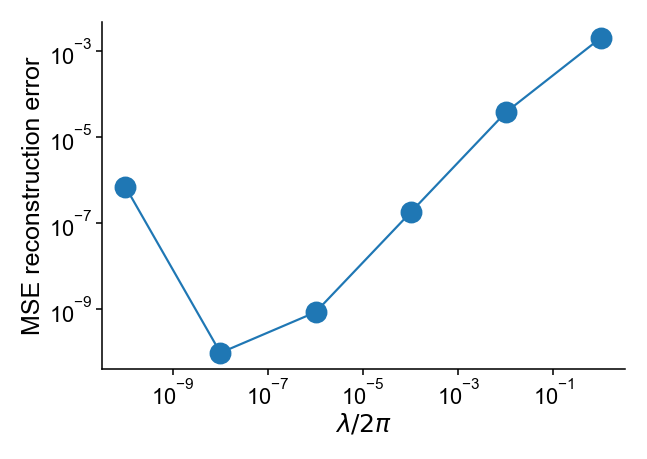

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from ring import style

fname = "../data/pc_convergence_grid.npz"  # your saved file

data = np.load(fname, allow_pickle=True)
lamda_vals = data["lamda_vals"]
err_grid = data["err_grid"]  # shape: (len(lamda_vals), len(c_vals))

# error doesn't depend on c → just take the first column (or mean across c)
err_vs_lambda = err_grid[:, 0]

fig = plt.figure(figsize=(style.FULL_W, 2.4))
ax = fig.add_axes([0.35, 0.22, 0.30, 0.68])  # centered small plot on a FULL_W canvas
ax.loglog(lamda_vals, err_vs_lambda, marker='o')
ax.set_xlabel("$\\lambda$")
ax.set_ylabel("mean squared flow")

# save WITHOUT bbox_inches="tight" so the FULL_W canvas + surrounding
# whitespace is kept instead of cropping back to the small axes.
if SAVE_FIGURES:
    plt.savefig("../figures/error_vs_regularization.pdf")


